In [41]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import pandas
import requests

In [22]:
hdul_files = ["data/080905499_PH00.fits","data/080810549_PH00.fits","data/080804972_PH00.fits"]

hdul_image = fits.open(hdul_files[2])
data = hdul_image[1].data

In [23]:
conversion_x = []
conversion_y = []
for i in range(0, len(data)):
    conversion_y.append(data[i][0])
    conversion_x.append(data[i][9])

<StemContainer object of 3 artists>

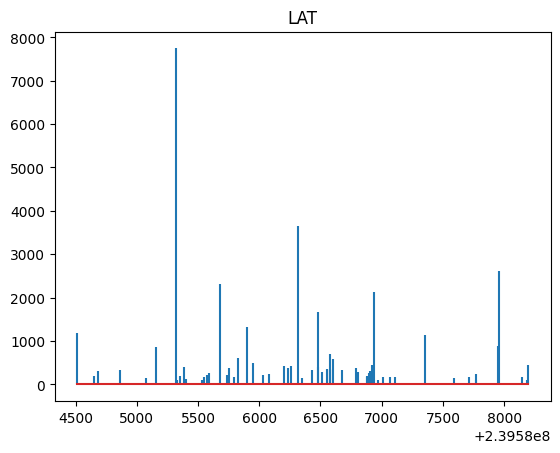

In [24]:
plt.title("LAT")
plt.stem(conversion_x,conversion_y, markerfmt="")

In [25]:
max = 0
max_time = 0
max_len = int(len(conversion_y))
for i in range(0, max_len):
    if conversion_y[i] > max:
        if conversion_y[i] < 1000000:
            max = conversion_y[i]
            max_time = conversion_x[i]
print("len: " + str(max_time) + "\n max: " + str(max))

len: 239585323.0784644
 max: 7745.0415


In [26]:
242308736.538152 - 242310179.44432482

-1442.906172811985

In [33]:
r = hdul_image[1].data[0][1] #RA 328.6675 
r

np.float32(0.24818772)

In [34]:
d = hdul_image[1].data[0][2] #DEC -53.184611
d

np.float32(-69.09762)

In [40]:
m = np.sqrt((360 - 328.6675 - r)**2 + (d+53.184611)**2)
m

np.float32(34.920742)

In [42]:
r = requests.get("https://icecube.wisc.edu/~grbweb_public/GRBweb2.sqlite")
f = open('GRBweb2.sqlite', 'wb').write(r.content)

In [43]:
db = sqlite3.connect('GRBweb2.sqlite')

In [49]:
Sum_table = pandas.read_sql_query("SELECT * from Summary", db)
Sum_table = Sum_table.sort_values("GRB_name_Fermi")
indices = np.where(Sum_table == "GRB080804972")
row_indices, col_indices = indices[0], indices[1]
index = Sum_table.iloc[row_indices].to_numpy()[0][0] - 1

#Sum_table.iloc[row_indices].T100.get(index)
#Sum_table.iloc[row_indices].T0.get(index)
#Sum_table.iloc[row_indices].GRB_name.get(index)
web_r = Sum_table.iloc[row_indices].ra.get(index)
web_d = Sum_table.iloc[row_indices].decl.get(index)
Sum_table.iloc[row_indices]

,id,GRB_name,GRB_name_Fermi,T0,T0_source,ra,ra_source,decl,decl_source,pos_error,...,fluence,fluence_source,fluence_error,fluence_error_source,redshift,redshift_source,T100,GBM_located,mjd,mjd_source
75,76,GRB080804A,GRB080804972,84014.0,"GCN_circulars,Swift Det",328.6675,Swift,-53.184611,Swift,0.000052,...,0.000009,Fermi_GBM,1.058900e-07,Fermi_GBM,2.2045,NaN,34.0,0,54682.972384,"GCN_circulars,Swift Det"
